# Identificación de Operadores Ineficaces — CallMeMaybe

### Estructura
1. Importar librerías y cargar datos
2. EDA (Análisis Exploratorio)
   - Exploración inicial
   - Limpieza de datos
   - Visualizaciones
3. Identificar operadores ineficaces
   - Llamadas entrantes perdidas
   - Tiempo de espera
   - Llamadas salientes bajas
4. Pruebas estadísticas
5. Conclusiones

# 1. Cargar los datos. 

In [2]:
# importar las librerías

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


In [3]:
# cargar los datasets
df = pd.read_csv('telecom_dataset_new.csv')
clients = pd.read_csv('telecom_clients.csv') 

print('Dataset principal:', df.shape)
print('Dataset clientes:', clients.shape)

Dataset principal: (53902, 9)
Dataset clientes: (732, 3)


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  str    
 2   direction            53902 non-null  str    
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(1), str(2)
memory usage: 3.3+ MB


In [5]:
clients.info()

<class 'pandas.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   user_id      732 non-null    int64
 1   tariff_plan  732 non-null    str  
 2   date_start   732 non-null    str  
dtypes: int64(1), str(2)
memory usage: 17.3 KB


Contamos con valores nulos en el operator_id y las fechas en ambos datasets se encuentran en str, por lo que toca hacer el la limpieza correspondiente de los datos. 

In [6]:
df.head()

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.0,True,3,0,5
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,True,1,0,1
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,False,1,10,18
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.0,True,3,0,25


In [7]:
clients.head()

,user_id,tariff_plan,date_start
0,166713,A,2019-08-15
1,166901,A,2019-08-23
2,168527,A,2019-10-29
3,167097,A,2019-09-01
4,168193,A,2019-10-16


# 2. EDA (Anáslisis exploratorio de los datos)

In [10]:
df['date'] = pd.to_datetime(df['date'], utc=True)

clients['date_start'] = pd.to_datetime(clients['date_start'])

Se realizaron los cambios correpondientes de STR a datetime. Para el dataset principal se mantiene la zona horaria, y, para el de clientes se pasa a datetime nada más. 

In [14]:
# valores nulos en el dataset principal
print(df.isnull().sum())

user_id                   0
date                      0
direction                 0
internal                117
operator_id            8172
is_missed_call            0
calls_count               0
call_duration             0
total_call_duration       0
dtype: int64


In [24]:
df['internal'] = df['internal'].fillna(False)

Las llamadas con internal nulo parecen ser únicamente llamadas entrantes donde no se registró si fueron internas o no. Probablemente el sistema no marcó este campo para llamadas entrantes, lo que indica un vacío en la captura de datos pero no un error crítico. Se rellenan con false. 

In [23]:
df['operator_missing'] = df['operator_id'].isna()
df.groupby(['operator_missing', 'is_missed_call']).size()

operator_missing  is_missed_call
False             False             30212
                  True              15518
True              False               122
                  True               8050
dtype: int64

In [29]:
df['operator_id_filled'] = df['operator_id'].fillna(-1)

La mayoría de las llamadas sin operador (8172) son llamadas perdidas (8050). Esto significa que cuando no hay operador asignado, casi siempre la llamada fue perdida. Los valores nulos de operator_id fueron rellenados con -1 porque no se confunde con ningún operador real y permite graficar sin perder filas.

# 3. Visualizaciones de las variables claves

In [ ]:
# calcular el tiempo de espera
df['waiting_time'] = df['total_call_duration'] - df['call_duration']

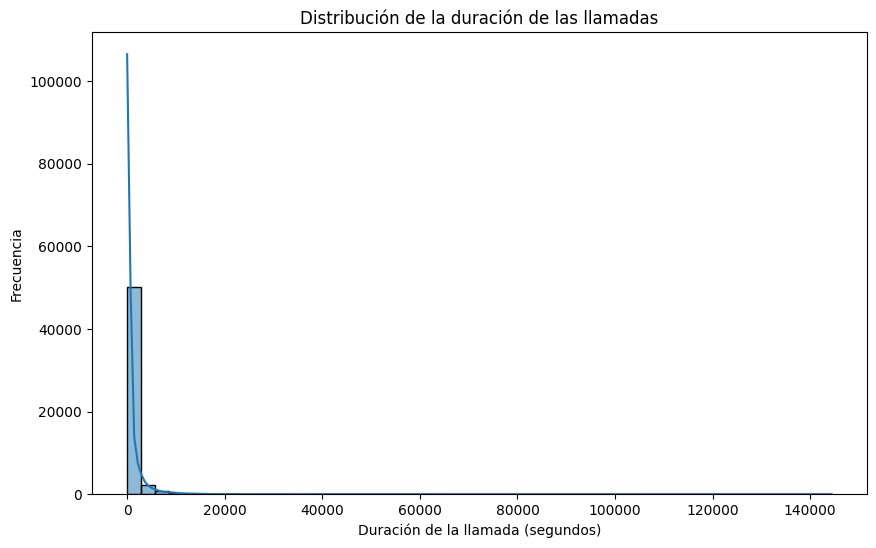

In [32]:
# histograma de la duración de las llamadas
plt.figure(figsize=(10, 6))
sns.histplot(df['call_duration'], bins=50, kde=True)
plt.title('Distribución de la duración de las llamadas')
plt.xlabel('Duración de la llamada (segundos)')
plt.ylabel('Frecuencia')
plt.show()

El gráfico muestra que existen muchas llamadas cortas, cola larga por llamadas largas.

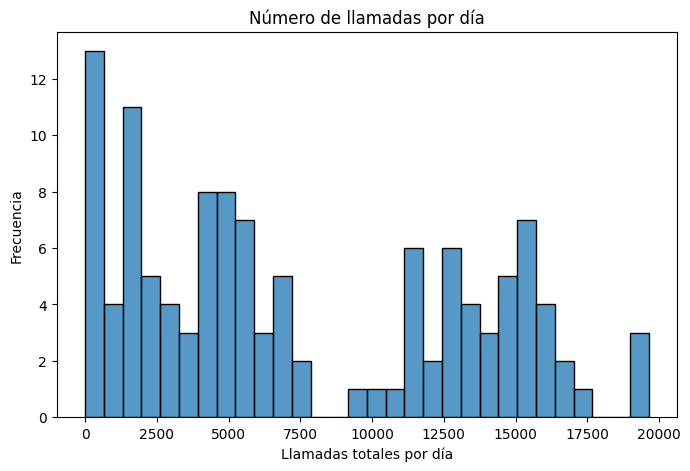

In [35]:
# histograma del numero de llamadas por día
df['date_only'] = df['date'].dt.date
calls_per_day = df.groupby('date_only')['calls_count'].sum().reset_index()


plt.figure(figsize=(8,5))
sns.histplot(calls_per_day['calls_count'], bins=30)
plt.title("Número de llamadas por día")
plt.xlabel("Llamadas totales por día")
plt.ylabel("Frecuencia")
plt.show()

La distribución de llamadas por día muestra que el uso del sistema es muy desigual y presenta dos comportamientos principales:

- Muchos días con baja actividad (0–7.500)
- Un grupo menor pero significativo de días con cargas muy altas (10.000–17.500)

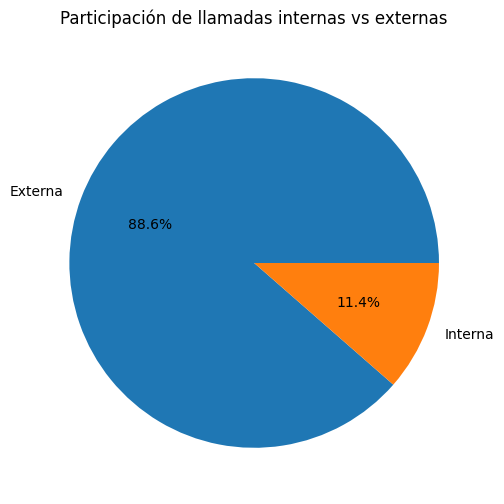

In [36]:
# llamadas internas vs llamadas externas

df['internal'] = df['internal'].fillna(False)

plt.figure(figsize=(6,6))
df['internal'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    labels=['Externa','Interna'],
)
plt.title("Participación de llamadas internas vs externas")
plt.ylabel("")
plt.show()


La operación de CallMeMaybe está fuertemente orientada hacia el cliente externo. La baja proporción de llamadas internas sugiere que los operadores dedican casi todo su tiempo a interacción con usuarios fuera de la organización, y por lo tanto los indicadores de eficiencia deben enfocarse especialmente en la gestión de llamadas externas.

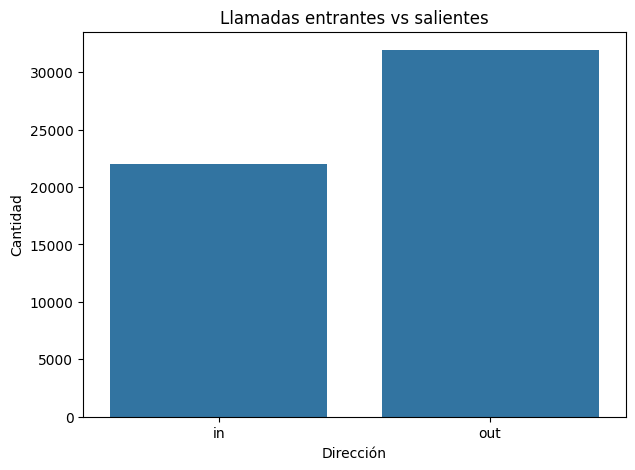

In [37]:
# Direcciones entrantes vs salientes
plt.figure(figsize=(7,5))
sns.countplot(x='direction', data=df)
plt.title("Llamadas entrantes vs salientes")
plt.xlabel("Dirección")
plt.ylabel("Cantidad")
plt.show()

El sistema maneja significativamente más llamadas salientes que entrantes, lo que sugiere una operación centrada en actividades proactivas como ventas o seguimiento.

# 4. Operadores ineficaces